In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("car_retail_sales_dataset_modified.csv")
df.head()

,date,year,month,week_of_year,day_of_week,is_weekend,dealer_id,city,region,brand,...,transmission,base_price,discount,final_price,promotion_type,inventory_available,online_leads,test_drives_booked,units_sold,revenue
0,01-01-2021,2021,1,53,4,0,D044,Hyderabad,South,Honda,...,Manual,1198004,110862,1087142,Cashback,52,26,11,4,4348568
1,01-01-2021,2021,1,53,4,0,D047,Hyderabad,South,Hyundai,...,Manual,1711058,149796,1561262,Zero Downpayment,20,23,11,3,4683786
2,01-01-2021,2021,1,53,4,0,D022,Bangalore,South,Mahindra,...,Manual,1365312,138254,1227058,NaN,44,39,22,2,2454116
3,01-01-2021,2021,1,53,4,0,D017,Hyderabad,South,Honda,...,Manual,1793301,54344,1738957,Exchange Offer,49,30,16,1,1738957
4,01-01-2021,2021,1,53,4,0,D013,Kolkata,East,Hyundai,...,Automatic,2540132,132613,2407519,NaN,49,24,7,1,2407519


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79187 entries, 0 to 79186
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   date                 79187 non-null  object
 1   year                 79187 non-null  int64 
 2   month                79187 non-null  int64 
 3   week_of_year         79187 non-null  int64 
 4   day_of_week          79187 non-null  int64 
 5   is_weekend           79187 non-null  int64 
 6   dealer_id            79187 non-null  object
 7   city                 79187 non-null  object
 8   region               79187 non-null  object
 9   brand                79187 non-null  object
 10  model                79187 non-null  object
 11  vehicle_category     79187 non-null  object
 12  fuel_type            79187 non-null  object
 13  transmission         79187 non-null  object
 14  base_price           79187 non-null  int64 
 15  discount             79187 non-null  int64 
 16  fina

In [4]:
df = df[["date","dealer_id","brand", "model", "final_price", "units_sold", "revenue"]]
df.head()

,date,dealer_id,brand,model,final_price,units_sold,revenue
0,01-01-2021,D044,Honda,City,1087142,4,4348568
1,01-01-2021,D047,Hyundai,Creta,1561262,3,4683786
2,01-01-2021,D022,Mahindra,XUV700,1227058,2,2454116
3,01-01-2021,D017,Honda,Elevate,1738957,1,1738957
4,01-01-2021,D013,Hyundai,i20,2407519,1,2407519


In [5]:
df["brand"] = df["brand"].astype("category")
df["model"] = df["model"].astype("category")
df["dealer_id"] = df["dealer_id"].astype("category")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79187 entries, 0 to 79186
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   date         79187 non-null  object  
 1   dealer_id    79187 non-null  category
 2   brand        79187 non-null  category
 3   model        79187 non-null  category
 4   final_price  79187 non-null  int64   
 5   units_sold   79187 non-null  int64   
 6   revenue      79187 non-null  int64   
dtypes: category(3), int64(3), object(1)
memory usage: 2.6+ MB


In [7]:
df["date"] = pd.to_datetime(df["date"],format="%d-%m-%Y")
df["date"]

0       2021-01-01
1       2021-01-01
2       2021-01-01
3       2021-01-01
4       2021-01-01
           ...    
79182   2024-12-16
79183   2024-12-16
79184   2024-12-16
79185   2024-12-16
79186   2024-12-16
Name: date, Length: 79187, dtype: datetime64[ns]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79187 entries, 0 to 79186
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         79187 non-null  datetime64[ns]
 1   dealer_id    79187 non-null  category      
 2   brand        79187 non-null  category      
 3   model        79187 non-null  category      
 4   final_price  79187 non-null  int64         
 5   units_sold   79187 non-null  int64         
 6   revenue      79187 non-null  int64         
dtypes: category(3), datetime64[ns](1), int64(3)
memory usage: 2.6 MB


In [9]:
df["month"] = df["date"].dt.to_period("M")

# Seasional Trend (Revenue)

In [10]:
monthly_sales = df.pivot_table(values = "revenue", aggfunc = "sum", index = "month")
monthly_sales

,revenue
month,
2021-01,7100283216
2021-02,6562513694
2021-03,7333406301
2021-04,6797678967
2021-05,7022932300
2021-06,7129135780
2021-07,7281683939
2021-08,7388490907
2021-09,6848686712


In [11]:
monthly_sales_1 = monthly_sales[:-1]

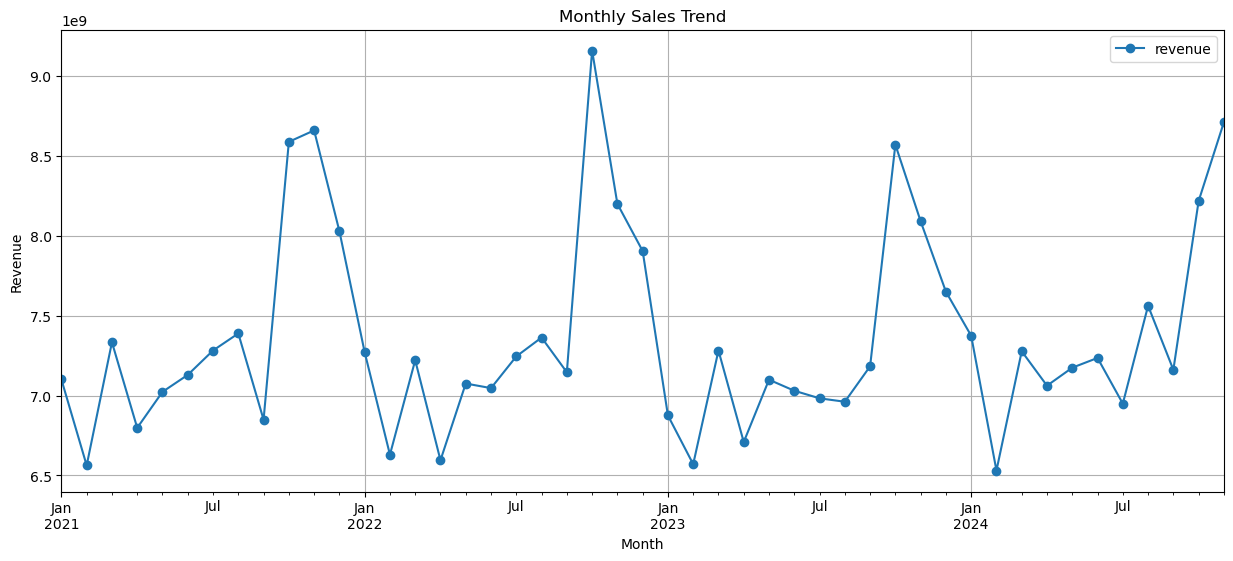

In [12]:
ax = monthly_sales_1.plot(kind="line", marker="o", figsize=(15,6))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid("True")

plt.show()

1. Oct, Nov, Dec - Seasional sale, peek sales
2. March is another peek but lower
3. Feb, April, Sep - Sales drop
4. May to Jul - consistant sales

# Current Month Trend

## Daily Trend

In [13]:
current_month = df['month'].max()
current_month_df = df.loc[df["month"]==current_month]
current_month_df

,date,dealer_id,brand,model,final_price,units_sold,revenue,month
78307,2024-12-01,D018,Toyota,Glanza,1543124,2,3086248,2024-12
78308,2024-12-01,D018,Tata,Harrier,1834057,1,1834057,2024-12
78309,2024-12-01,D024,Mahindra,XUV700,1325407,3,3976221,2024-12
78310,2024-12-01,D011,Tata,Nexon,610631,3,1831893,2024-12
78311,2024-12-01,D033,Mahindra,Scorpio,3173965,5,15869825,2024-12
...,...,...,...,...,...,...,...,...
79182,2024-12-16,D025,Honda,Amaze,2835353,1,2835353,2024-12
79183,2024-12-16,D002,Toyota,Fortuner,1638183,1,1638183,2024-12
79184,2024-12-16,D044,Mahindra,Scorpio,2882877,2,5765754,2024-12
79185,2024-12-16,D032,Hyundai,i20,2589305,2,5178610,2024-12


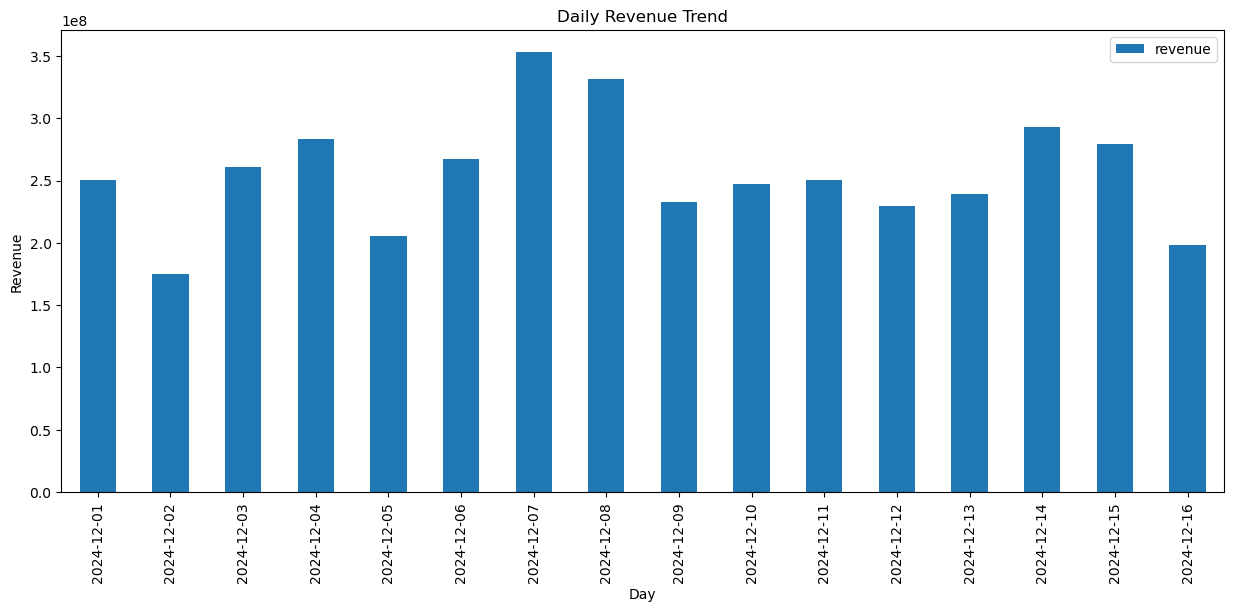

In [14]:
cm_daily_revenue = current_month_df.pivot_table(values = "revenue", aggfunc = "sum", index = "date")

cm_daily_revenue.index = cm_daily_revenue.index.date

# daily trend [bar graph]
cm_bar = cm_daily_revenue.plot(kind="bar", figsize=(15,6))
plt.title("Daily Revenue Trend")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.show()

## Daily Trend (cumulative) & Forcasting (Pacing)

###Core idea

You're mid-month with revenue so far (till day D). Each reference month tells you what fraction of its full-month revenue had arrived by that same day D. Invert that fraction and scale up your current partial actual.

###For any reference month:

completion_ratio = revenue_till_day_D / revenue_full_month

implied_forecast  = current_month_revenue_till_D / completion_ratio

Y-1 captures seasonality (same calendar month last year). M-1/M-2/M-3 capture recent pace. You then blend each reference month's implied forecast by its weight:

prediction = Σ ( weight_i × implied_forecast_i )

The trick that makes this valid: always cut every reference month at the same day-of-month D as your current partial data.

In [15]:
def monthly_sum(ref_month, D):
    """Revenue up to day D, and full-month revenue, for one month period.
    Returns (till_D, full_month)."""
    daily = df.loc[df["month"] == ref_month]
    daily = daily.groupby(daily["date"].dt.day)["revenue"].sum().sort_index()
    till_D     = daily[daily.index <= D].sum()
    full_month = daily.sum()
    return till_D, full_month

# Current Month
current_month = df["month"].max()
cm = df.loc[df["month"] == current_month]
D = int(cm["date"].dt.day.max())
current_till_D = cm.loc[cm["date"].dt.day <= D, "revenue"].sum()


# Reference Months
ref = {"Y-1": current_month - 12, 
       "M-3": current_month - 3, 
       "M-2": current_month - 2, 
       "M-1": current_month - 1}


weights = {"Y-1": 0.2, 
       "M-3": 0.16, 
       "M-2": 0.24, 
       "M-1": 0.4}

rows, prediction = [], 0.0

for name, ref in ref.items():
    till_D, full = monthly_sum(ref, D)
    ratio = till_D / full
    implied = current_till_D / ratio
    prediction += weights[name] * implied
    rows.append([name, str(ref), round(ratio,3), round(implied), weights[name]])

output = pd.DataFrame(rows, columns=["ref","month","completion_ratio","implied_forecast","weight"])

print(f"Summary: {output}")
print(f"\nCutoff day D = {D}")
print(f"Current revenue till date: {current_till_D:,.0f}")
print(f"Predicted month-end revenue: {prediction:,.0f}")

Summary:    ref    month  completion_ratio  implied_forecast  weight
0  Y-1  2023-12             0.532        7701560419    0.20
1  M-3  2024-09             0.532        7707002530    0.16
2  M-2  2024-10             0.495        8281222101    0.24
3  M-1  2024-11             0.562        7292374472    0.40

Cutoff day D = 16
Current revenue till date: 4,097,485,007
Predicted month-end revenue: 7,677,875,582


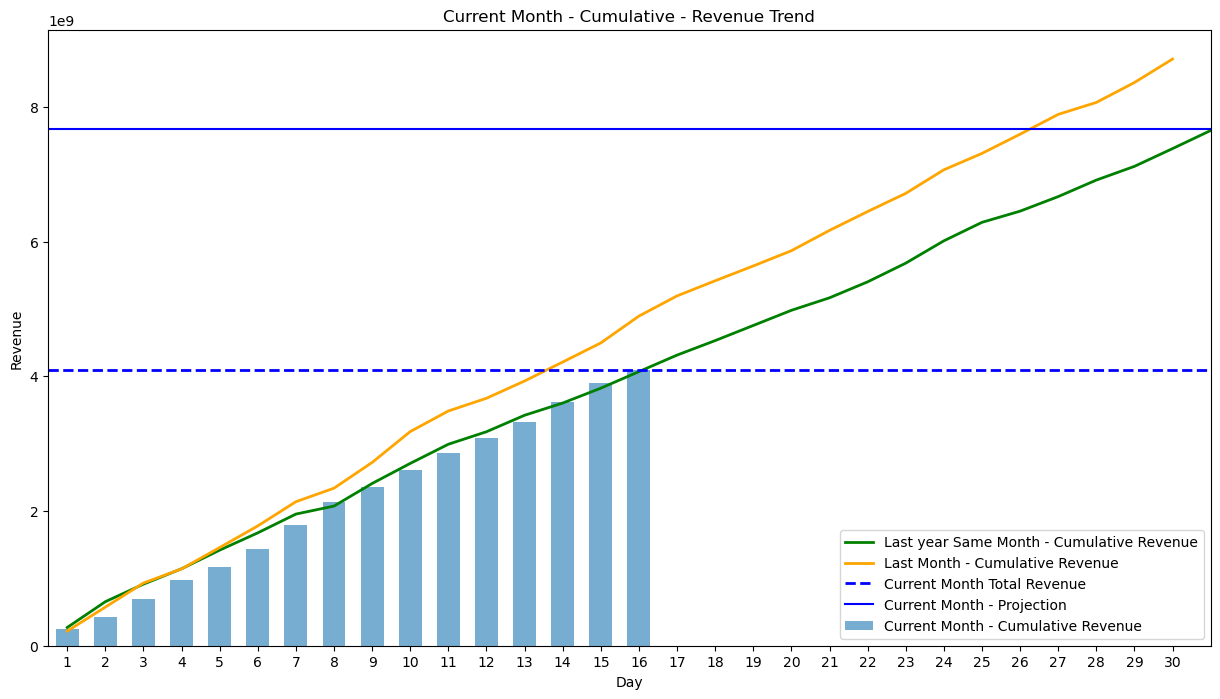

In [18]:
# Current month cumulative sum

cm_cum_revenue = current_month_df.pivot_table(values = "revenue", aggfunc = "sum", index = "date")
cm_cum_revenue["cumulative_revenue"] = cm_cum_revenue["revenue"].cumsum()
cm_cum_revenue.index = cm_cum_revenue.index.day

fig, ax = plt.subplots(figsize=(15,8))


#cm_bar = cm_cum_revenue["cumulative_revenue"].plot(kind="bar", ax=ax, label= "Current Month - Cumulative Revenue")

ax.bar(cm_cum_revenue.index, cm_cum_revenue["cumulative_revenue"], width=0.6, alpha=0.6, label="Current Month - Cumulative Revenue")


# last year same month, cumulative sum

current_month_last_year = current_month.month
last_year = current_month.year - 1
last_year_cm = df.loc[ (df["date"].dt.month == current_month_last_year) & 
                            (df["date"].dt.year == last_year)]

last_year_cm_cum_revenue = last_year_cm.pivot_table(values = "revenue", aggfunc = "sum", index = "date")
last_year_cm_cum_revenue["cumulative_revenue"] = last_year_cm_cum_revenue["revenue"].cumsum()

last_year_cm_cum_revenue.index = last_year_cm_cum_revenue.index.day

#last_year_cm_cum_line = last_year_cm_cum_revenue["cumulative_revenue"].plot(kind="line", ax=ax, color="green", linewidth = 2, label = "Last year Same Month - Cumulative Revenue")

ax.plot(last_year_cm_cum_revenue.index, last_year_cm_cum_revenue["cumulative_revenue"], color="green", linewidth = 2, label = "Last year Same Month - Cumulative Revenue")

# Last month - Cumulative Revenue

last_month = current_month.month - 1

last_month_df = df.loc[ (df["date"].dt.month == last_month) & 
                        (df["date"].dt.year == current_month.year)]

last_month_cum_revenue = last_month_df.pivot_table(values="revenue", aggfunc = "sum", index = "date")
last_month_cum_revenue["cumulative_revenue"] = last_month_cum_revenue["revenue"].cumsum()

last_month_cum_revenue.index = last_month_cum_revenue.index.day

#last_month_cum_revenue_bar = last_month_cum_revenue["cumulative_revenue"].plot(kind="line", ax=ax, color="orange", linewidth = 2, label = "Last Month - Cumulative Revenue")

ax.plot(last_month_cum_revenue.index, last_month_cum_revenue["cumulative_revenue"], color="orange", linewidth = 2, label = "Last Month - Cumulative Revenue")

ax.axhline(y=current_till_D, color="blue", linewidth = 2, linestyle = '--', dash_capstyle = "butt", label = "Current Month Total Revenue")
ax.axhline(y=prediction, color = "blue", dash_joinstyle = "round", label = "Current Month - Projection")


#previous_month
plt.title("Current Month - Cumulative - Revenue Trend")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.legend()
ax.set_xticks(range(1, 31))
ax.set_xlim(0.5, 31)

plt.savefig('Current Month - Cumulative - Revenue Trend.png')

plt.show()

In [17]:
def forecast(target_month, D, weights):
    refs = {"Y-1": target_month-12, "M-3": target_month-3,
            "M-2": target_month-2,  "M-1": target_month-1}
    till_D, _ = monthly_sum(target_month, D)          # current month's actual so far
    num = wsum = 0.0
    for name, ref in refs.items():
        ref_till, ref_full = monthly_sum(ref, D)
        ratio    = ref_till / ref_full            # completion ratio
        num     += weights[name] * (till_D / ratio)
        wsum    += weights[name]
    return num / wsum if wsum else np.nan

def backtest(D, weights=None, min_history=13):
    if weights is None:
        weights = {"Y-1": 0.20, "M-3": 0.16, "M-2": 0.24, "M-1": 0.40}
    months    = sorted(df["month"].unique())
    completed = months[:-1]                       # last month partial -> exclude
    rows = []
    for i, m in enumerate(completed):
        if i < min_history:                       # need Y-1 + M-3 to exist
            continue
        _, actual = monthly_sum(m, D)                 # full-month total = actual
        fc = forecast(m, D, weights)
        if pd.notna(fc) and actual:
            rows.append([str(m), round(actual), round(fc),
                         round(abs(fc-actual)/actual*100, 2), (fc-actual)**2]) # month, actual value, forecasted value, APE (Absolute Percentage Error), Squared Error
    res = pd.DataFrame(rows, columns=["month","actual","forecast","APE_%","SE"])
    if res.empty:
        print("Not enough history to back-test at this D.")
        return res
    mape = res["APE_%"].mean()
    rmse = np.sqrt(res["SE"].mean())
    print(res[["month","actual","forecast","APE_%"]].to_string(index=False))
    print(f"\nBack-test at day D={D}  |  months tested: {len(res)}")
    print(f"MAPE : {mape:.2f}%")
    print(f"RMSE : {rmse:,.0f}")
    return res

backtest_results = backtest(D=14)

  month     actual   forecast  APE_%
2022-02 6629581898 7283439499   9.86
2022-03 7221006796 7006716891   2.97
2022-04 6594823843 6660322321   0.99
2022-05 7075068211 6930120888   2.05
2022-06 7046273630 7481001465   6.17
2022-07 7244711464 7234097692   0.15
2022-08 7362815714 7288112575   1.01
2022-09 7145603951 7131312958   0.20
2022-10 9159319706 9039228813   1.31
2022-11 8199686513 8499967912   3.66
2022-12 7904736210 7713720664   2.42
2023-01 6875011340 6712911553   2.36
2023-02 6570247624 7064734303   7.53
2023-03 7281562728 6828623740   6.22
2023-04 6708921154 7106398326   5.92
2023-05 7099024319 6774801775   4.57
2023-06 7029904906 6987902380   0.60
2023-07 6982418827 6915462203   0.96
2023-08 6961027935 6806396524   2.22
2023-09 7182753812 7619060248   6.07
2023-10 8570101317 8781110940   2.46
2023-11 8090475838 8264967857   2.16
2023-12 7649918075 7603879513   0.60
2024-01 7373839865 6813056916   7.61
2024-02 6530518045 6993190245   7.08
2024-03 7276801698 7322643454   0.63
2

## What can be added or improve
1. Confidence band. The spread of the four completion ratios is your uncertainty. Report the prediction from the min and max ratio as a low/high range — shows you quantify uncertainty, not just point-guess.
Instead of having a abolute forecasting, confidence band with min and max range to show the forecasting.
3. Tune the weights against the back-test. Don't hand-pick 0.2/0.3/0.5 — grid-search or optimize the weights to minimize back-test error, then show the improvement. That turns "I chose weights" into "I validated and optimized weights."
that resolve the higher Absolute Percentage Error by adjusting the weightage according the seasionlality